Loading cached data from /tmp/watermark_data.pkl
Loaded 100 samples

Stage 2: Evaluating with 7B model


`torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

Computing Z-scores...


100%|██████████| 100/100 [00:00<00:00, 138.92it/s]


Computing PPL...
Computing human Z-scores...


100%|██████████| 100/100 [00:00<00:00, 147.00it/s]



Results Summary
baseline  : Z-score = 0.105 ± 0.964
kgw       : Z-score = 5.782 ± 1.188
unbiased  : Z-score = 0.003 ± 0.954
human     : Z-score = -0.026 ± 1.155
baseline  : PPL = 5.62 ± 2.01
kgw       : PPL = 7.11 ± 2.16
unbiased  : PPL = 13.47 ± 3.90
Saved plot to watermark_results.png


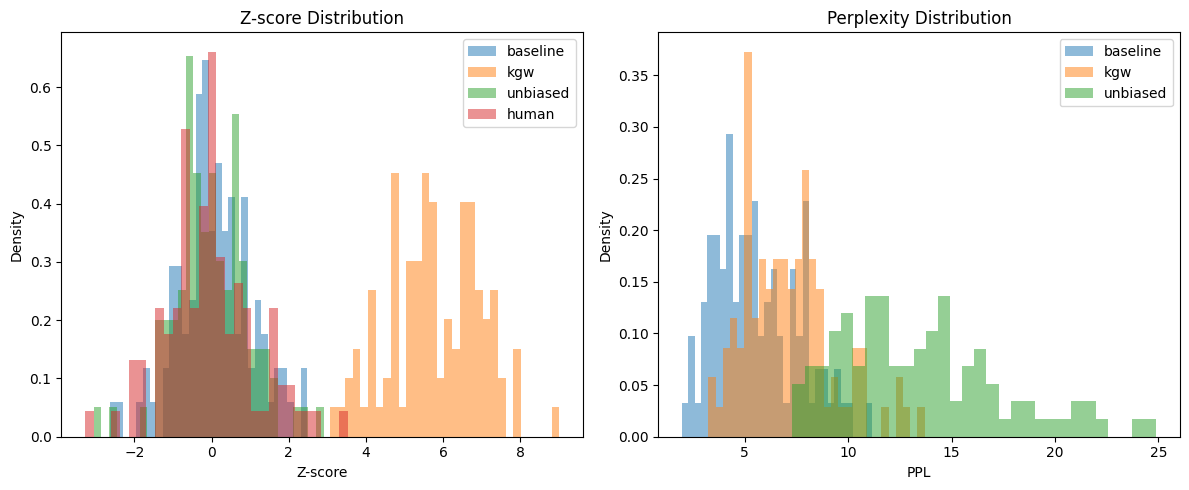


Done!


In [1]:
import torch
import numpy as np
import json
import pickle
import gc
import os
from tqdm import tqdm
from transformers import AutoModelForCausalLM, AutoTokenizer, LogitsProcessor, LogitsProcessorList
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
import hashlib

# ==========================================
# 0. 全局优化（4090 24GB）
# ==========================================
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True

# 优化内存分配策略，减少碎片
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True,max_split_size_mb:512"


# ==========================================
# 1. 稳定 hash
# ==========================================
def stable_hash(x):
    return int(hashlib.sha256(str(x).encode()).hexdigest(), 16) % (2**32)


# ==========================================
# 2. Watermark Processors
# ==========================================
class KGWLogitsProcessor(LogitsProcessor):
    def __init__(self, tokenizer, gamma=0.5, delta=2.0, hash_key=42, device="cpu"):
        self.gamma = gamma
        self.delta = delta
        self.hash_key = hash_key
        self.device = device
        self.tokenizer = tokenizer
        self.cache = {}

    def _get_mask(self, prev_token, vocab_size):
        if prev_token in self.cache:
            return self.cache[prev_token]

        seed = stable_hash((prev_token, self.hash_key))
        gen = torch.Generator(device=self.device)
        gen.manual_seed(seed)

        probs = torch.rand(vocab_size, generator=gen, device=self.device)
        mask = probs < self.gamma
        self.cache[prev_token] = mask
        return mask

    def __call__(self, input_ids, scores):
        vocab_size = scores.shape[-1]
        for b in range(input_ids.shape[0]):
            prev = input_ids[b, -1].item()
            mask = self._get_mask(prev, vocab_size)
            scores[b][mask] += self.delta
        return scores


class UnbiasedLogitsProcessor(LogitsProcessor):
    def __init__(self, gamma=0.5, hash_key=42, device="cpu"):
        self.gamma = gamma
        self.hash_key = hash_key
        self.device = device
        self.cache = {}

    def _get_mask(self, prev_token, vocab_size):
        if prev_token in self.cache:
            return self.cache[prev_token]

        seed = stable_hash((prev_token, self.hash_key))
        gen = torch.Generator(device=self.device)
        gen.manual_seed(seed)

        probs = torch.rand(vocab_size, generator=gen, device=self.device)
        mask = probs < self.gamma
        self.cache[prev_token] = mask
        return mask

    def __call__(self, input_ids, scores):
        log_probs = torch.nn.functional.log_softmax(scores, dim=-1)
        probs = torch.exp(log_probs)
        
        new_probs_list = []
        for b in range(input_ids.shape[0]):
            prev = input_ids[b, -1].item()
            vocab_size = scores.shape[-1]
            mask = self._get_mask(prev, vocab_size)
            
            p_green = probs[b][mask].sum()
            p_red = probs[b][~mask].sum()
            
            new_probs = probs[b].clone()
            if p_green > 0:
                new_probs[mask] = probs[b][mask] * self.gamma / p_green
            if p_red > 0:
                new_probs[~mask] = probs[b][~mask] * (1 - self.gamma) / p_red
            
            # 重新归一化
            new_probs = new_probs / (new_probs.sum() + 1e-10)
            new_probs_list.append(new_probs)
        
        final_probs = torch.stack(new_probs_list)
        return torch.log(final_probs + 1e-10)


# ==========================================
# 3. Detector
# ==========================================
class KGWDetector:
    def __init__(self, tokenizer, gamma=0.5, hash_key=42, device="cpu"):
        self.gamma = gamma
        self.hash_key = hash_key
        self.vocab_size = len(tokenizer)  # 使用 len() 包含 added tokens
        self.device = device
        self.cache = {}

    def _get_mask(self, prev_token):
        if prev_token in self.cache:
            return self.cache[prev_token]

        seed = stable_hash((prev_token, self.hash_key))
        gen = torch.Generator(device=self.device)
        gen.manual_seed(seed)

        probs = torch.rand(self.vocab_size, generator=gen, device=self.device)
        mask = probs < self.gamma
        self.cache[prev_token] = mask
        return mask

    def detect(self, tokens, prompt_len):
        gen_len = len(tokens) - prompt_len
        if gen_len <= 0:
            return 0.0

        green = 0
        for i in range(prompt_len, len(tokens)):
            prev = tokens[i-1].item()
            cur = tokens[i].item()
            
            # 安全检查：跳过超出 vocab 范围的 token
            if cur >= self.vocab_size:
                continue
                
            if self._get_mask(prev)[cur]:
                green += 1

        expected = self.gamma * gen_len
        var = gen_len * self.gamma * (1 - self.gamma)
        z = (green - expected) / (np.sqrt(var) + 1e-6)
        return float(z)


# ==========================================
# 4. Engine（Batch生成，内存优化版）
# ==========================================
class WatermarkEngine:
    def __init__(self, model, tokenizer, device):
        self.model = model
        self.tokenizer = tokenizer
        self.device = device

    @torch.no_grad()
    def generate(self, prompts, processors, gen_config, batch_size=4):
        """
        分批生成，降低内存压力
        batch_size=4 适合 4090 24GB
        """
        results = []

        for i in tqdm(range(0, len(prompts), batch_size), desc="Generating"):
            batch_prompts = prompts[i:i+batch_size]

            inputs = self.tokenizer(
                batch_prompts,
                return_tensors="pt",
                padding=True,
                truncation=True
            ).to(self.device)

            prompt_lens = (inputs.input_ids != self.tokenizer.pad_token_id).sum(dim=1)

            outputs = {}
            # 基线生成
            outputs["baseline"] = self.model.generate(**inputs, **gen_config)
            
            # 每次生成后清理缓存（可选，影响速度但节省内存）
            # torch.cuda.empty_cache()

            # 水印生成
            for name, proc in processors.items():
                outputs[name] = self.model.generate(
                    **inputs,
                    logits_processor=LogitsProcessorList([proc]),
                    **gen_config
                )

            for b in range(len(batch_prompts)):
                results.append({
                    "prompt_len": int(prompt_lens[b]),
                    "tokens": {k: v[b].cpu().tolist() for k, v in outputs.items()}
                })
            
            # 清理 GPU tensor
            del inputs, outputs
            torch.cuda.empty_cache()

        return results


# ==========================================
# 5. Evaluator（Batch PPL，支持小batch）
# ==========================================
class Evaluator:
    def __init__(self, detector, model, tokenizer):
        self.detector = detector
        self.model = model
        self.tokenizer = tokenizer

    def calc_ppl_batch(self, texts, max_batch=4):
        """
        分批计算PPL，避免OOM
        """
        all_ppls = []
        
        for i in range(0, len(texts), max_batch):
            batch = texts[i:i+max_batch]
            
            inputs = self.tokenizer(
                batch, 
                return_tensors="pt", 
                padding=True, 
                truncation=True, 
                max_length=512
            ).to(self.model.device)
            
            with torch.no_grad():
                outputs = self.model(**inputs, labels=inputs["input_ids"])
            
            # 手动计算 perplexity
            logits = outputs.logits
            labels = inputs["input_ids"]
            attention_mask = inputs["attention_mask"]
            
            # Shift for next-token prediction
            shift_logits = logits[:, :-1, :].contiguous()
            shift_labels = labels[:, 1:].contiguous()
            shift_mask = attention_mask[:, 1:].contiguous()
            
            # 计算 loss
            loss_fct = torch.nn.CrossEntropyLoss(reduction='none')
            loss = loss_fct(
                shift_logits.view(-1, shift_logits.size(-1)), 
                shift_labels.view(-1)
            )
            loss = loss.view(shift_labels.size())
            
            # Masked average，防止除0
            denominator = shift_mask.sum(dim=1)
            denominator = torch.clamp(denominator, min=1e-6)
            masked_loss = (loss * shift_mask).sum(dim=1) / denominator
            
            all_ppls.extend(torch.exp(masked_loss).cpu().tolist())
            
            # 清理
            del inputs, outputs, logits, loss
            torch.cuda.empty_cache()

        return all_ppls

    def evaluate(self, data, human):
        z_dict = {"baseline": [], "kgw": [], "unbiased": []}
        ppl_dict = {"baseline": [], "kgw": [], "unbiased": []}

        # ===== Z-score =====
        print("Computing Z-scores...")
        for item in tqdm(data):
            prompt_len = item["prompt_len"]
            for name in z_dict:
                tokens = torch.tensor(item["tokens"][name])
                z = self.detector.detect(tokens, prompt_len)
                z_dict[name].append(z)

        # ===== PPL（分批计算）=====
        print("Computing PPL...")
        texts_dict = {k: [] for k in ppl_dict}
        for item in data:
            for name in ppl_dict:
                tokens = torch.tensor(item["tokens"][name])
                # 只解码生成的部分
                generated = tokens[item["prompt_len"]:]
                txt = self.tokenizer.decode(generated, skip_special_tokens=True)
                texts_dict[name].append(txt)

        for name in ppl_dict:
            ppls = self.calc_ppl_batch(texts_dict[name], max_batch=4)
            ppl_dict[name] = ppls

        # ===== human z-score =====
        print("Computing human Z-scores...")
        z_human = []
        for txt in tqdm(human):
            tokens = self.tokenizer.encode(txt, return_tensors="pt")[0]
            z = self.detector.detect(tokens, prompt_len=0)
            z_human.append(z)

        return z_dict, ppl_dict, z_human


# ==========================================
# 6. 可视化
# ==========================================
def plot_all(z_dict, z_human, ppl_dict, save_path=None):
    plt.figure(figsize=(12, 5))
    
    # Z-score 分布
    plt.subplot(1, 2, 1)
    for k, v in z_dict.items():
        plt.hist(v, bins=30, alpha=0.5, label=k, density=True)
    plt.hist(z_human, bins=30, alpha=0.5, label="human", density=True)
    plt.legend()
    plt.title("Z-score Distribution")
    plt.xlabel("Z-score")
    plt.ylabel("Density")
    
    # PPL 分布
    plt.subplot(1, 2, 2)
    for k, v in ppl_dict.items():
        if len(v) > 0:
            plt.hist(v, bins=30, alpha=0.5, label=k, density=True)
    plt.legend()
    plt.title("Perplexity Distribution")
    plt.xlabel("PPL")
    plt.ylabel("Density")
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"Saved plot to {save_path}")
    
    plt.show()


# ==========================================
# 7. main（分阶段加载，避免OOM）
# ==========================================
def main():
    device = "cuda"
    
    # 路径配置
    model_small = "/root/autodl-tmp/Qwen2.5-1.5B-Instruct"
    model_large = "/root/autodl-tmp/Qwen2.5-7B-Instruct"
    data_cache_path = "/tmp/watermark_data.pkl"  # 临时保存生成结果
    
    # 检查是否已有缓存数据（方便调试评估阶段）
    if os.path.exists(data_cache_path):
        print(f"Loading cached data from {data_cache_path}")
        with open(data_cache_path, 'rb') as f:
            data = pickle.load(f)
        print(f"Loaded {len(data)} samples")
    else:
        # ===== 阶段1: 生成数据（只用 1.5B 模型）=====
        print("=" * 50)
        print("Stage 1: Generating with 1.5B model")
        print("=" * 50)
        
        tokenizer1 = AutoTokenizer.from_pretrained(model_small, trust_remote_code=True)
        tokenizer1.pad_token = tokenizer1.eos_token
        tokenizer1.padding_side = "left"
        
        model1 = AutoModelForCausalLM.from_pretrained(
            model_small,
            torch_dtype=torch.float16,
            trust_remote_code=True
        ).to(device)
        
        # 可选：编译加速（可能增加内存峰值）
        # model1 = torch.compile(model1)
        
        processors = {
            "kgw": KGWLogitsProcessor(tokenizer1, gamma=0.5, delta=2.0, device=device),
            "unbiased": UnbiasedLogitsProcessor(gamma=0.5, device=device)
        }
        
        engine = WatermarkEngine(model1, tokenizer1, device)
        
        # 加载 prompts
        try:
            with open("prompts.json", 'r') as f:
                prompts = json.load(f)["test_prompts"]
        except FileNotFoundError:
            print("Warning: prompts.json not found, using dummy data")
            prompts = ["This is a test prompt."] * 10
        
        gen_config = {
            "max_new_tokens": 128,
            "do_sample": True,
            "temperature": 0.7,
            "top_p": 0.9,
            "use_cache": True,
            "pad_token_id": tokenizer1.pad_token_id,
            "eos_token_id": tokenizer1.eos_token_id,
        }
        
        # 生成（batch_size=4 适合 4090）
        data = engine.generate(prompts, processors, gen_config, batch_size=4)
        
        # 保存结果
        with open(data_cache_path, 'wb') as f:
            pickle.dump(data, f)
        print(f"Saved generated data to {data_cache_path}")
        
        # 彻底清理 1.5B 模型内存
        del model1, engine, processors
        gc.collect()
        torch.cuda.empty_cache()
        torch.cuda.synchronize()
        print(f"GPU memory after cleanup: {torch.cuda.memory_allocated() / 1e9:.2f} GB")
    
    # ===== 阶段2: 评估（只用 7B 模型）=====
    print("\n" + "=" * 50)
    print("Stage 2: Evaluating with 7B model")
    print("=" * 50)
    
    # 重新加载 tokenizer1 用于 detector（不需要模型）
    tokenizer1 = AutoTokenizer.from_pretrained(model_small, trust_remote_code=True)
    tokenizer1.pad_token = tokenizer1.eos_token
    
    tokenizer2 = AutoTokenizer.from_pretrained(model_large, trust_remote_code=True)
    tokenizer2.pad_token = tokenizer2.eos_token
    tokenizer2.padding_side = "right"
    
    # 加载 7B 模型
    model2 = AutoModelForCausalLM.from_pretrained(
        model_large,
        torch_dtype=torch.float16,
        trust_remote_code=True
    ).to(device)
    
    # model2 = torch.compile(model2)
    
    # 创建检测器和评估器
    detector = KGWDetector(tokenizer1, gamma=0.5, device=device)
    evaluator = Evaluator(detector, model2, tokenizer2)
    
    # 加载 human texts
    try:
        with open("human_texts.json", 'r') as f:
            human = json.load(f)["human_texts"]
    except FileNotFoundError:
        print("Warning: human_texts.json not found, using dummy data")
        human = ["This is human written text."] * 10
    
    # 评估
    z_dict, ppl_dict, z_human = evaluator.evaluate(data, human)
    
    # 打印统计信息
    print("\n" + "=" * 50)
    print("Results Summary")
    print("=" * 50)
    for name in ["baseline", "kgw", "unbiased"]:
        z_scores = z_dict[name]
        print(f"{name:10s}: Z-score = {np.mean(z_scores):.3f} ± {np.std(z_scores):.3f}")
    print(f"{'human':10s}: Z-score = {np.mean(z_human):.3f} ± {np.std(z_human):.3f}")
    
    for name in ["baseline", "kgw", "unbiased"]:
        if len(ppl_dict[name]) > 0:
            ppls = ppl_dict[name]
            print(f"{name:10s}: PPL = {np.mean(ppls):.2f} ± {np.std(ppls):.2f}")
    
    # 可视化
    plot_all(z_dict, z_human, ppl_dict, save_path="watermark_results.png")
    
    # 清理
    del model2, evaluator, detector
    torch.cuda.empty_cache()
    
    print("\nDone!")


if __name__ == "__main__":
    main()